## Task: Next Word Prediction (Language Modeling)
### Problem : Given a sequence of words, predict the next word

#### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense, LSTM, GRU

#### Sample Dataset

In [2]:
text = """
    I love machine learning
    I love deep learning
    deep learning is powerful
    machine learning is fun
    artificial intelligence is the future
    I enjoy learning new things
"""

#### Tokenization

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

In [4]:
total_words = len(tokenizer.word_index) + 1
total_words

16

#### Create input sequences

In [5]:
input_sequences = []

for line in text.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

input_sequences

[[2, 4],
 [2, 4, 5],
 [2, 4, 5, 1],
 [2, 4],
 [2, 4, 6],
 [2, 4, 6, 1],
 [6, 1],
 [6, 1, 3],
 [6, 1, 3, 7],
 [5, 1],
 [5, 1, 3],
 [5, 1, 3, 8],
 [9, 10],
 [9, 10, 3],
 [9, 10, 3, 11],
 [9, 10, 3, 11, 12],
 [2, 13],
 [2, 13, 1],
 [2, 13, 1, 14],
 [2, 13, 1, 14, 15]]

#### Padding

In [6]:
max_seq_len = max(len(seq) for seq in input_sequences)
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding="pre"))
input_sequences

array([[ 0,  0,  0,  2,  4],
       [ 0,  0,  2,  4,  5],
       [ 0,  2,  4,  5,  1],
       [ 0,  0,  0,  2,  4],
       [ 0,  0,  2,  4,  6],
       [ 0,  2,  4,  6,  1],
       [ 0,  0,  0,  6,  1],
       [ 0,  0,  6,  1,  3],
       [ 0,  6,  1,  3,  7],
       [ 0,  0,  0,  5,  1],
       [ 0,  0,  5,  1,  3],
       [ 0,  5,  1,  3,  8],
       [ 0,  0,  0,  9, 10],
       [ 0,  0,  9, 10,  3],
       [ 0,  9, 10,  3, 11],
       [ 9, 10,  3, 11, 12],
       [ 0,  0,  0,  2, 13],
       [ 0,  0,  2, 13,  1],
       [ 0,  2, 13,  1, 14],
       [ 2, 13,  1, 14, 15]], dtype=int32)

#### Split into X & y

In [7]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [8]:
X

array([[ 0,  0,  0,  2],
       [ 0,  0,  2,  4],
       [ 0,  2,  4,  5],
       [ 0,  0,  0,  2],
       [ 0,  0,  2,  4],
       [ 0,  2,  4,  6],
       [ 0,  0,  0,  6],
       [ 0,  0,  6,  1],
       [ 0,  6,  1,  3],
       [ 0,  0,  0,  5],
       [ 0,  0,  5,  1],
       [ 0,  5,  1,  3],
       [ 0,  0,  0,  9],
       [ 0,  0,  9, 10],
       [ 0,  9, 10,  3],
       [ 9, 10,  3, 11],
       [ 0,  0,  0,  2],
       [ 0,  0,  2, 13],
       [ 0,  2, 13,  1],
       [ 2, 13,  1, 14]], dtype=int32)

In [9]:
y

array([ 4,  5,  1,  4,  6,  1,  1,  3,  7,  1,  3,  8, 10,  3, 11, 12, 13,
        1, 14, 15], dtype=int32)

In [10]:
y = tf.keras.utils.to_categorical(y, num_classes=total_words)
y

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,

### Model Variants
#### 1. Simple RNN

In [11]:
model_rnn = Sequential()

model_rnn.add(Embedding(input_dim=total_words, output_dim=50, input_shape=(max_seq_len-1,)))
model_rnn.add(SimpleRNN(100))
model_rnn.add(Dense(total_words, activation="softmax"))

model_rnn.summary()

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 4, 50)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        15,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,616 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,516 (68.42 KB)

 Trainable params: 17,516 (68.42 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile & Train

In [12]:
model_rnn.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [13]:
history_rnn = model_rnn.fit(X, y, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step - accuracy: 0.1000 - loss: 2.7751
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1500 - loss: 2.7334
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2500 - loss: 2.6919
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3000 - loss: 2.6497
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3000 - loss: 2.6060
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3000 - loss: 2.5601
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3500 - loss: 2.5117
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3500 - loss: 2.4606
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3500 - loss: 2.4073
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3500 - loss: 2.3529
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3500 - loss: 2.2992
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3500 - l

#### Prediction

In [14]:
def predict_next_word(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding="pre")

    predicted = np.argmax(model_rnn.predict(token_list), axis=-1)

    for word, index in tokenizer.word_index.items():
        if index == predicted:
            return word

In [15]:
predict_next_word("i love machine")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


'learning'

#### 2. LSTM

In [16]:
model_lstm = Sequential()

model_lstm.add(Embedding(input_dim=total_words, output_dim=50, input_shape=(max_seq_len-1,)))
model_lstm.add(LSTM(100))
model_lstm.add(Dense(total_words, activation="softmax"))

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 4, 50)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,616 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,816 (245.38 KB)

 Trainable params: 62,816 (245.38 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_lstm.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [18]:
history_lstm = model_lstm.fit(X, y, epochs=100, verbose=1)

Epoch 1/100


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step - accuracy: 0.0000e+00 - loss: 2.7742
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2500 - loss: 2.7671
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2000 - loss: 2.7601
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2500 - loss: 2.7528
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2500 - loss: 2.7452
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2500 - loss: 2.7371
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2500 - loss: 2.7285
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2500 - loss: 2.7190
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2500 - loss: 2.7086
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2500 - loss: 2.6971
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2500 - loss: 2.6842
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2500 - loss: 2.6

In [19]:
def predict_next_word(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
    
    predicted = np.argmax(model_lstm.predict(token_list), axis=-1)
    
    for word, index in tokenizer.word_index.items():
        if index == predicted:
            return word

In [20]:
predict_next_word("i love machine")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


'learning'

#### 3. GRU

In [21]:
model_gru = Sequential()

model_gru.add(Embedding(input_dim=total_words, output_dim=50, input_shape=(max_seq_len-1,)))
model_gru.add(GRU(100))
model_gru.add(Dense(total_words, activation="softmax"))

model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 4, 50)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100)            │        45,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,616 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,016 (187.56 KB)

 Trainable params: 48,016 (187.56 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model_gru.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [23]:
history_gru = model_gru.fit(X, y, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1000 - loss: 2.7676
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3000 - loss: 2.7569
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4500 - loss: 2.7461
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4000 - loss: 2.7352
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4000 - loss: 2.7238
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4000 - loss: 2.7119
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3500 - loss: 2.6994
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3500 - loss: 2.6861
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3000 - loss: 2.6718
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3000 - loss: 2.6563
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2500 - loss: 2.6396
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2500 - loss

In [24]:
def predict_next_word(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
    
    predicted = np.argmax(model_gru.predict(token_list), axis=-1)
    
    for word, index in tokenizer.word_index.items():
        if index == predicted:
            return word

In [25]:
predict_next_word("i love machine")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


'learning'

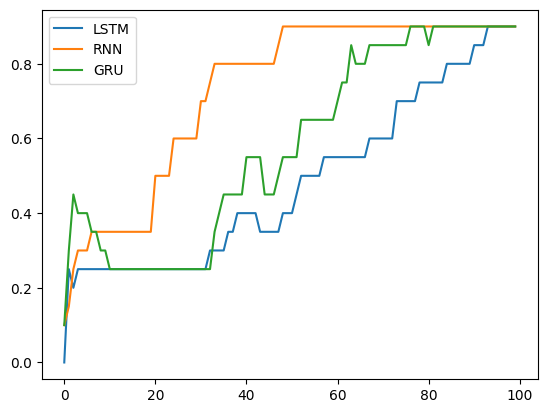

In [26]:
plt.plot(history_lstm.history['accuracy'], label='LSTM')
plt.plot(history_rnn.history['accuracy'], label='RNN')
plt.plot(history_gru.history['accuracy'], label='GRU')
plt.legend()
plt.show()

In [27]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
        
        predicted = np.argmax(model.predict(token_list), axis=-1)
        
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        
        seed_text += " " + output_word
    
    return seed_text

In [28]:
# generate_text(model, "i love machine")

In [29]:
def sample_with_temperature(preds, temperature=1.0):
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)

In [30]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

        preds = model.predict(token_list)[0]

        predicted_index = sample_with_temperature(preds, temperature=0.8)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [31]:
generate_text(model_rnn, "i love machine learning", 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


'i love machine learning things fun i love deep learning things powerful things the'

In [32]:
generate_text(model_lstm, "i love machine learning", 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


'i love machine learning new powerful future things intelligence fun future things the the'

In [33]:
generate_text(model_gru, "i love machine learning", 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


'i love machine learning new things future fun the fun future the future machine'